---
format:
    html: default
    ipynb: default
jupyter: python3
---


## Explaining CNNs


In this assignment you implement two explainer algorithms for Convolutional Neural Networks (CNNs) and use them to inspect a model you have already trained. An explainer answers a question that accuracy alone cannot: which parts of an input drove this particular prediction? For an image classifier that answer takes the form of a saliency map, and a trustworthy map should highlight the animal rather than the background, a watermark, or some dataset artifact the model latched onto.

We invite you to watch the following video, which sets the context and walks through the tools you can use. Click the thumbnail to open it on YouTube.

[![Watch the assignment introduction on YouTube](https://img.youtube.com/vi/Am2EF9CLu-g/hqdefault.jpg)](https://www.youtube.com/watch?v=Am2EF9CLu-g)

In the [cats vs dogs](https://huggingface.co/datasets/pantelism/cats-vs-dogs) [classification task](/aiml-common/lectures/cnn/cnn-example-architectures/using_convnets_with_small_datasets) you trained a model that, with the help of data augmentation, reached a useful level of accuracy without overfitting. That trained model is your subject here. You do not retrain it or change its architecture; you attach explainers to it and interpret what they reveal about how it decides.

### The two methods you will implement

**Integrated gradients** ([Sundararajan et al., 2017](https://arxiv.org/abs/1703.01365)) attributes a prediction to individual input pixels. It picks a baseline image (commonly an all-black image, which the model should find uninformative) and integrates the gradient of the class score along the straight-line path from that baseline to the actual input. The result is a per-pixel attribution with two properties that plain input gradients lack: completeness, meaning the attributions sum to the difference in model output between the input and the baseline, and robustness to saturated activations, where a plain gradient would read close to zero even though the feature mattered.

**Grad-CAM** ([Selvaraju et al., 2016](https://arxiv.org/abs/1610.02391)) produces a coarse, class-discriminative heatmap. It takes the feature maps of a convolutional layer, usually the last one, and weights each map by the gradient of the class score flowing into it. Because it works at the resolution of a deep feature map rather than the raw pixels, it localizes the region the network used instead of scoring every pixel.

The two methods sit at opposite ends of a resolution trade-off: integrated gradients is fine-grained and pixel-level, Grad-CAM is coarse and region-level. Running both on the same image and noting where they agree, and where they do not, is the heart of this assignment.

We strongly advise PyTorch with [Captum](https://captum.ai/tutorials/) unless you already have Keras/TF expertise, because both methods ship as ready implementations there (`IntegratedGradients` and `LayerGradCam`). You are free to use the high-level APIs of the framework of your choice.

### What to submit

For each method, in the cells below:

- A markdown explanation written so that anyone who understands how a CNN works can follow it. Cover the intuition, the role of the baseline (integrated gradients) or the target layer (Grad-CAM), and one limitation of the method.
- Working code that runs the explainer on at least three correctly classified images and at least one image the model got wrong.
- The resulting maps overlaid on the input images, each with a one-line caption stating what the map suggests the model attended to.

### How your work is evaluated

- Correctness: the right baseline, the right target layer, and gradients taken with respect to the predicted class rather than a fixed label.
- Visualization quality: maps are overlaid on the inputs, readable, and labeled.
- Depth of interpretation: noting that a map "looks reasonable" is not enough. Point to where the two methods agree, where they disagree, and what the misclassified example tells you about what the model actually learned.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torchvision import transforms

from captum.attr import IntegratedGradients
from captum.attr import LayerGradCam
from captum.attr import LayerAttribution

IMG_SIZE = 150

BATCH_SIZE = 32

LR = 1e-4

EPOCHS_BASELINE = 20

SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available()else "cpu")

print("Device:", DEVICE)

ds_dict = load_dataset("pantelism/cats-vs-dogs")

label_names = ds_dict["train"].features["label"].names

print(f"Train {len(ds_dict['train'])}")

print(f"Validation {len(ds_dict['validation'])}")

print(f"Test {len(ds_dict['test'])}")

print(label_names)

class CatsDogsDataset(Dataset):

    def __init__(self,hf_dataset,transform):

        self.data = hf_dataset

        self.transform = transform

    def __len__(self):

        return len(self.data)

    def __getitem__(self, idx):

        sample = self.data[idx]

        img = sample["image"].convert("RGB")

        label = float(sample["label"])

        return (self.transform(img),label
)

basic_tf = transforms.Compose([
    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5]
    )
])

aug_tf = transforms.Compose([
    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(40),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.2, 0.2),
        shear=20
    ),
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.8, 1.0)
    ),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5]
    )
])

def make_loader(hf_split,tf,shuffle=False):

    return DataLoader(
        CatsDogsDataset(hf_split,tf),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=2,
        pin_memory=True
    )


train_loader_basic = make_loader(ds_dict["train"],basic_tf,True)

val_loader = make_loader(ds_dict["validation"],basic_tf)

test_loader = make_loader(ds_dict["test"],basic_tf)

class SmallConvNet(nn.Module):

    def __init__(self,dropout=False):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3),

            nn.ReLU(),

            nn.Conv2d(128,128,3),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Dropout(0.5)
            if dropout
            else nn.Identity(),

            nn.Linear(128 * 16 * 16,512),

            nn.ReLU(),

            nn.Linear(512,1)
        )

    def forward(self,x):

        x = self.features(x)

        x = x.view(x.size(0),-1)

        return self.classifier(x).squeeze(1)

def train_model(model,train_loader,val_loader,epochs,lr=LR):

    model = model.to(DEVICE)

    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.RMSprop(model.parameters(),lr=lr)

    for epoch in range(epochs):

        model.train()

        for imgs, labels in train_loader:

            imgs = imgs.to(DEVICE)

            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            logits = model(imgs)

            loss = criterion(logits,labels)

            loss.backward()

            optimizer.step()

        print(
            f"Epoch {epoch+1}/{epochs}"
        )

    return model

torch.manual_seed(SEED)

model_baseline = SmallConvNet()

model_baseline = train_model(model_baseline,train_loader_basic,val_loader,EPOCHS_BASELINE)

model_baseline.eval()

print(model_baseline.features)

target_layer = model_baseline.features[8]


model_baseline
test_loader
label_names
DEVICE


/home/steve/Desktop/SUMMER2026/CS375/eng-ai-agents/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Train 2000
Validation 1000
Test 1000
['cat', 'dog']
Epoch 1/20
Epoch 2/20
Epoch 3/20
Epoch 4/20
Epoch 5/20
Epoch 6/20
Epoch 7/20
Epoch 8/20
Epoch 9/20
Epoch 10/20
Epoch 11/20
Epoch 12/20
Epoch 13/20
Epoch 14/20
Epoch 15/20
Epoch 16/20
Epoch 17/20
Epoch 18/20
Epoch 19/20
Epoch 20/20
Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (7): ReLU()
  (8): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
  (9): ReLU()
  (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)


device(type='cuda')

Found 3 correct examples 

Found 1 incorrect examples
Example 1
Actual: cat
Predicted: cat


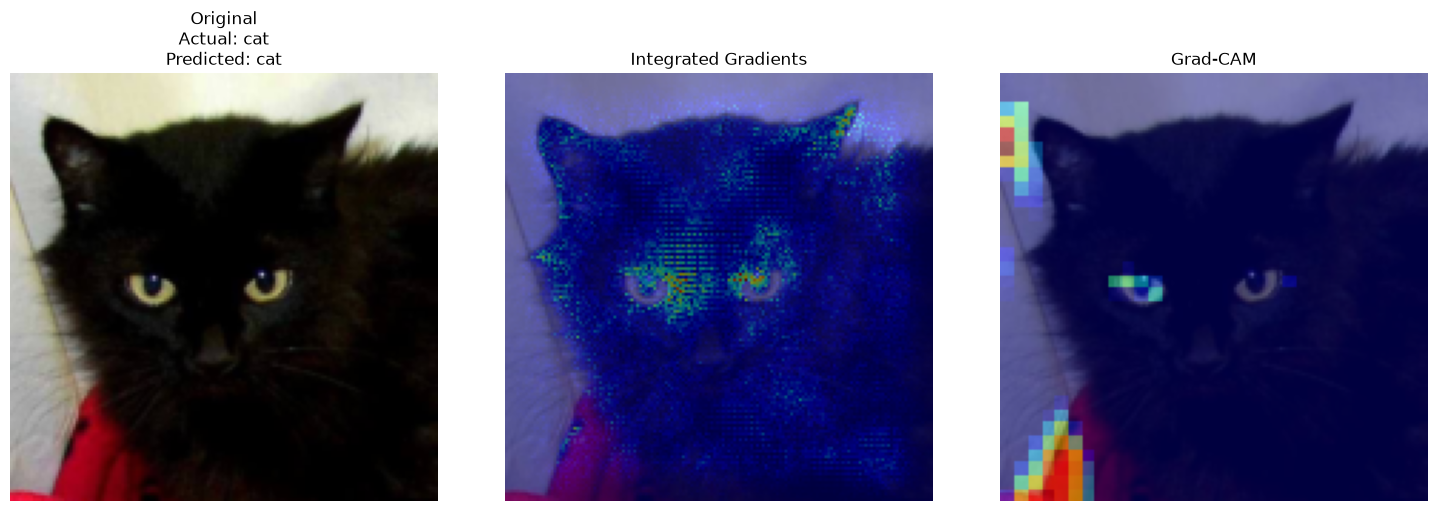

Example 2
Actual: cat
Predicted: cat


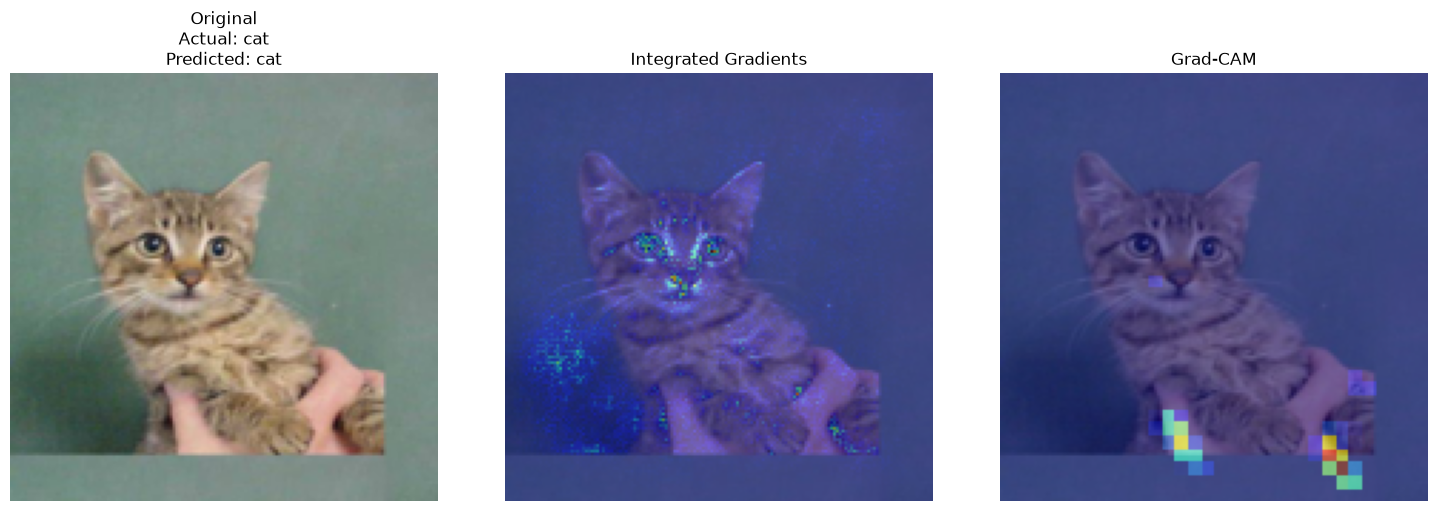

Example 3
Actual: cat
Predicted: cat


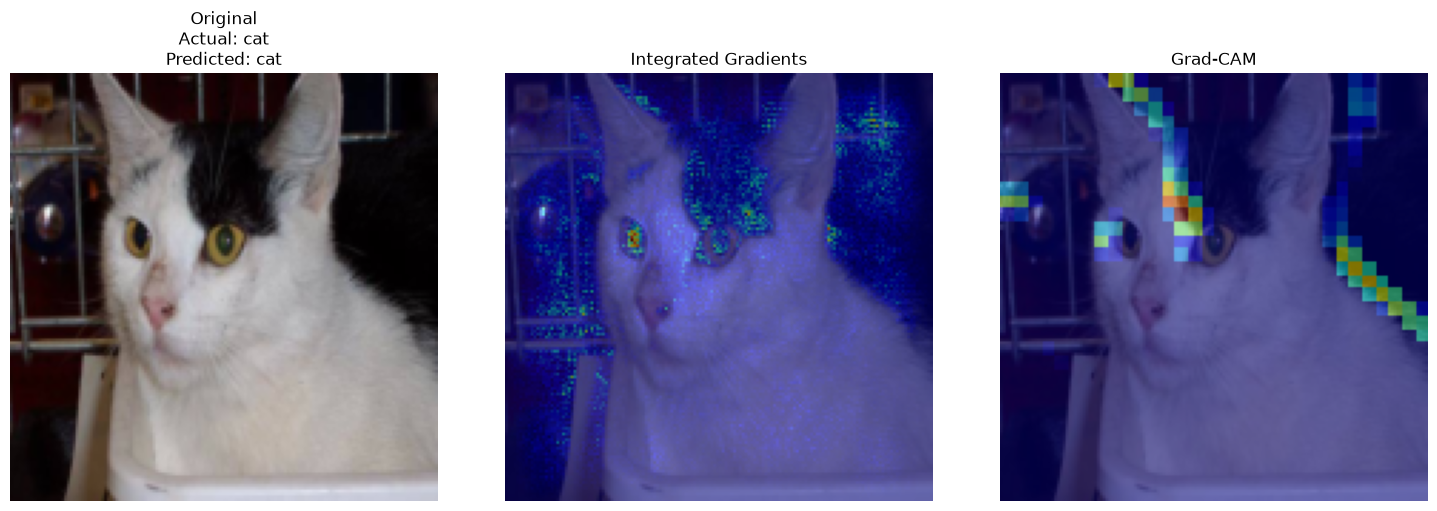

Example 4
Actual: cat
Predicted: dog


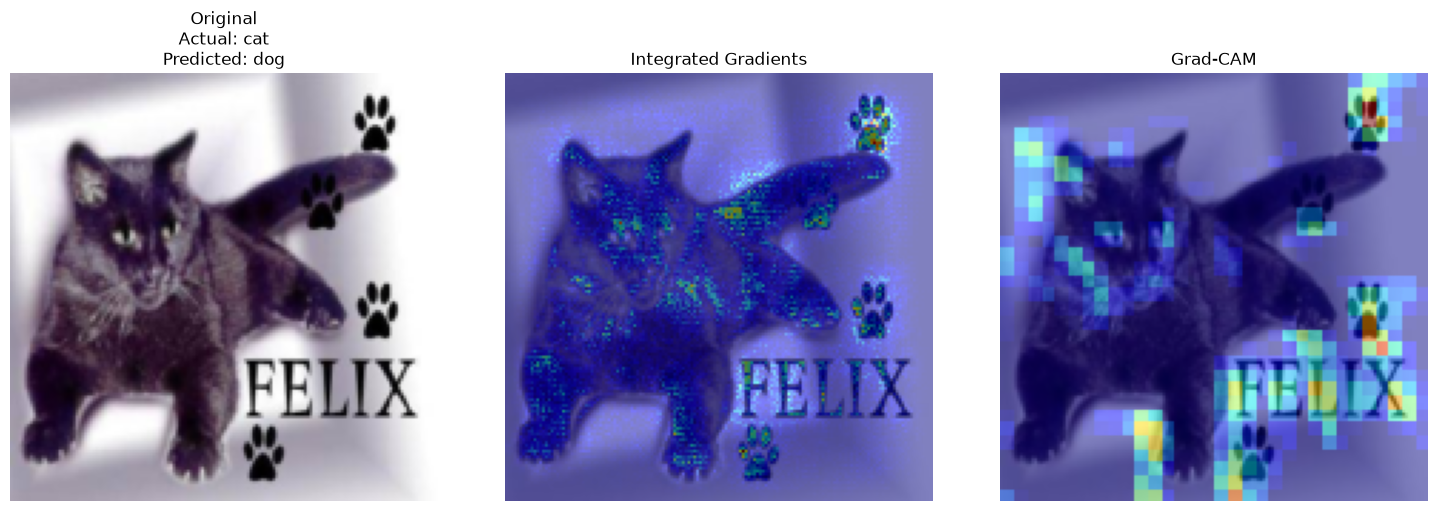

In [2]:
from captum.attr import IntegratedGradients 
from captum.attr import LayerGradCam
from captum.attr import LayerAttribution

import numpy as np 
import matplotlib.pyplot as plt 

def denormalize(img):
    img = img.detach().cpu()
    img = img * 0.5 + 0.5
    img = img.clamp(0,10)
    return img


correct_examples = []
wrong_examples = []

with torch.no_grad():

    for imgs,labels in test_loader:
        imgs = imgs.to(DEVICE)
        logits = model_baseline(imgs)
        preds = (logits > 0).float()

        for i in range(len(imgs)):

            image = imgs[i].cpu()
            actual = int(labels[i].item())
            pred = int(preds[i].item())

            if actual == pred:

                if len(correct_examples) < 3:
                    correct_examples.append((image,actual,pred))

            else:

                if len(wrong_examples) < 1:

                    wrong_examples.append((image,actual,pred))

            if(len(correct_examples) >= 3 and len(wrong_examples) >= 1):
                break

        if(len(correct_examples) >= 3) and (len(wrong_examples) >= 1):
            break

examples = correct_examples + wrong_examples

print(f"Found {len(correct_examples)} correct examples \n")
print(f"Found {len(wrong_examples)} incorrect examples")

ig = IntegratedGradients(model_baseline)

def compute_integrated_gradients(image):
    
    image = image.unsqueeze(0).to(DEVICE)
    baseline = torch.zeros_like(image)
    attributions = ig.attribute(image,baselines=baseline,n_steps=50)

    attributions = attributions.squeeze(0)

    return attributions.cpu()

def ig_to_heatmap(attr):

    heatmap = attr.abs().sum(dim=0)
    heatmap = heatmap.detach().cpu().numpy()

    heatmap = (heatmap-heatmap.min())/(heatmap.max() - heatmap.min())

    return heatmap

target_layer = model_baseline.features[9]
gradcam = LayerGradCam(model_baseline,target_layer)

def compute_gradcam(image):

    image = image.unsqueeze(0).to(DEVICE)
    cam = gradcam.attribute(image)
    cam = LayerAttribution.interpolate(cam,image.shape[2:])
    cam = cam.squeeze()
    cam = cam.detach().cpu().numpy()
    cam = np.maximum(cam,0)
    cam = (cam - cam.min())/(cam.max() - cam.min() + 1e-8)

    return cam

def show_explanations(image, actual, pred):

    ig_attr = compute_integrated_gradients(image)

    ig_heatmap = ig_to_heatmap(ig_attr)

    gradcam_heatmap = compute_gradcam(image)

    display_img = denormalize(image)

    display_img = (display_img.permute(1, 2, 0).numpy())

    fig, axes = plt.subplots(1,3,figsize=(15, 5))

    axes[0].imshow(display_img)

    axes[0].set_title(f"Original\n"f"Actual: {label_names[actual]}\n"f"Predicted: {label_names[pred]}")

    axes[0].axis("off")

    axes[1].imshow(display_img)

    axes[1].imshow(ig_heatmap,cmap="jet",alpha=0.5)

    axes[1].set_title("Integrated Gradients")

    axes[1].axis("off")

    axes[2].imshow(display_img)

    axes[2].imshow(gradcam_heatmap,cmap="jet",alpha=0.5)

    axes[2].set_title("Grad-CAM")

    axes[2].axis("off")

    plt.tight_layout()

    plt.show()

for i, (image, actual, pred) in enumerate(examples):

    print("=" * 60)
    print(f"Example {i+1}")

    print(f"Actual: {label_names[actual]}")

    print(f"Predicted: {label_names[pred]}")

    show_explanations(image,actual,pred)



Integrated Gradients is a feature attribution method that explains a model prediction by measusing how each input pixel contributes to the output. Looking only at the gradient at the final image, computes gradients along a baseline image to the acutal image and gets results. The baseline represents an image with no useful information which all-black is used as the baseline. The attribution value for each pixel represents how much that pixel contributed to the model's prediction. The intuition of Integrated Gradients is the importantance with what pixels will consistently influence the prediction as the images changes from the baseline to the original. A limitation is that the explanation depends on the choice of the baseline, different baseline images can have different attribution maps that can affect the results. 

Grad-CAM explains CNN predictions by identifying the image regions that contributed most to the predicted class. Instead of assigning importance to individual pixels, it instead produces a coarse heatmap showing the areas that influenced the model's decision. The method uses the feature maps from the final convolutional layer of the network. The gradients of the predicted class are computed with respect to these feature maps, and the resulting weights are used to create a class-specific activation map.The intuition behind Grad-CAM is that the final convolutional layer contains high-level features such as eyes, ears, faces, and body shapes. By examining these feature maps, Grad-CAM can show where the model was looking when making its prediction. A limitation of Grad-CAM is its low spatial resolution, the heatmap is generated from deep feature maps that are smaller than the original image, the explanation is less precise than pixel-level methods such as Integrated Gradients.

Caption: The explanation maps focus on the cat's eyes, and head region, indicating that the model used characteristic cat features rather than the background.

Caption: The model focuses primarily on non cat features which gives less attention to the face or other cat features. This may explain why the image was incorrectly classified.

Both explanation methods generally focused on the animal rather than the background, which suggests that the CNN learned meaningful visual features related to cats and dogs. Integrated Gradients provided fine-grained pixel-level attributions and highlighted specific features such as eyes, ears, and face. Grad-CAM produced heatmaps that localized the regions of the image important to the prediction, typically covering the head and body of the cat. The two methods often agreed on the most important regions, especially around the face. However, Integrated Gradients revealed more detailed pixel-level information, while Grad-CAM emphasized larger semantic regions. For the misclassified image, both methods revealed that the model attended to features that were not related features, such as text or a paw that can be related but not in this case. Suggesting that the model may have learned to look at other features related to animals but not necessarily can be part of the main features to predict the animal.



